# Step 10 -- 2D Poisson Equation

The [Poisson equation](https://en.wikipedia.org/wiki/Poisson%27s_equation) adds a source term to the Laplace equation:

$$
\nabla^2 p = b
$$

**Physics:**  The Poisson equation is the **pressure equation** in incompressible fluid dynamics.  After discretising the Navier--Stokes momentum equations, we must solve a Poisson equation at every time step to enforce the divergence-free constraint. Mastering this solver is a prerequisite for Steps 12 and 13.

**What you will learn:**

1. How to solve the Poisson equation with three boundary-condition types
2. The connection between BC type and spectral method (DST / DCT / FFT)
3. How the solver converges as the grid is refined ($O(\Delta x^2)$)
4. Comparative wall-clock times for different BC types

## Arakawa C-Grid and Boundary Conditions

The solver operates on a 2D Arakawa C-grid where scalar fields (temperature, pressure, streamfunction) live at cell centres and velocity components live on cell faces:

```
       V_{j+1/2}
    ┌─────●─────┐
    │           │
 U  ●     T     ●  U
i-1/2   (i,j)    i+1/2
    │           │
    └─────●─────┘
       V_{j-1/2}
```

The spectral solver operates on **interior cells** only.  The boundary condition type determines which spectral transform is used.

Three BC types correspond to three spectral transforms:

| BC type | Transform | Ghost condition |
|---------|-----------|-----------------|
| Dirichlet ($\phi=0$) | DST | Antisymmetric |
| Neumann ($\partial\phi/\partial n=0$) | DCT | Symmetric |
| Periodic | FFT | Wrap-around |

In [1]:
from __future__ import annotations

import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import PoissonSolver2D

## 1. Dirichlet BCs (DST solver)

Homogeneous Dirichlet: $p = 0$ on all walls.

Test problem:
$p_{\text{exact}} = \sin(\pi x)\sin(\pi y)$,
$b = -2\pi^2 \sin(\pi x)\sin(\pi y)$.

In [2]:
def solve_dirichlet(nx: int, ny: int) -> tuple[float, float]:
    """Solve Dirichlet test problem and return (L2 error, time)."""
    solver = PoissonSolver2D.create(nx=nx, ny=ny, Lx=1.0, Ly=1.0, bc="dirichlet")
    x = jnp.arange(solver.grid.Nx) * solver.grid.dx
    y = jnp.arange(solver.grid.Ny) * solver.grid.dy
    X, Y = jnp.meshgrid(x, y)
    rhs = -2.0 * jnp.pi**2 * jnp.sin(jnp.pi * X) * jnp.sin(jnp.pi * Y)
    exact = jnp.sin(jnp.pi * X) * jnp.sin(jnp.pi * Y)
    # Warm up JIT
    phi = solver.solve(rhs)
    jax.block_until_ready(phi)
    t0 = time.perf_counter()
    phi = solver.solve(rhs)
    jax.block_until_ready(phi)
    elapsed = time.perf_counter() - t0
    err = float(jnp.sqrt(jnp.mean((phi[1:-1, 1:-1] - exact[1:-1, 1:-1]) ** 2)))
    return err, elapsed


nx_dir = 64
err_dir, time_dir = solve_dirichlet(nx_dir, nx_dir)
print(f"Dirichlet {nx_dir}x{nx_dir}: L2 error = {err_dir:.6e}, time = {time_dir:.4f}s")

Dirichlet 64x64: L2 error = 5.585729e-02, time = 0.0060s


Visualise the Dirichlet solution:

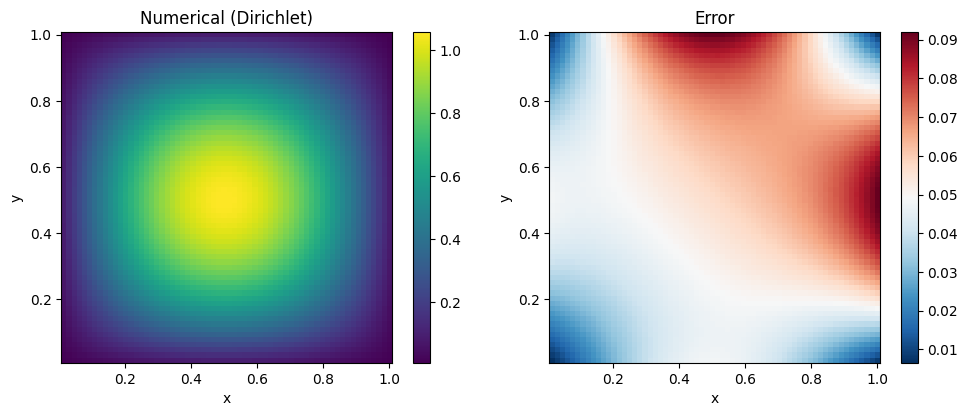

In [3]:
solver_dir = PoissonSolver2D.create(nx=64, ny=64, Lx=1.0, Ly=1.0, bc="dirichlet")
x = jnp.arange(solver_dir.grid.Nx) * solver_dir.grid.dx
y = jnp.arange(solver_dir.grid.Ny) * solver_dir.grid.dy
X, Y = jnp.meshgrid(x, y)
rhs_dir = -2.0 * jnp.pi**2 * jnp.sin(jnp.pi * X) * jnp.sin(jnp.pi * Y)
phi_dir = solver_dir.solve(rhs_dir)
exact_dir = jnp.sin(jnp.pi * X) * jnp.sin(jnp.pi * Y)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].pcolormesh(
    X[1:-1, 1:-1], Y[1:-1, 1:-1], phi_dir[1:-1, 1:-1], shading="auto"
)
axes[0].set_title("Numerical (Dirichlet)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    phi_dir[1:-1, 1:-1] - exact_dir[1:-1, 1:-1],
    shading="auto",
    cmap="RdBu_r",
)
axes[1].set_title("Error")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

## 2. Neumann BCs (DCT solver)

Homogeneous Neumann: $\partial p / \partial n = 0$ on all walls.

Test problem:
$p_{\text{exact}} = \cos(\pi x)\cos(\pi y)$,
$b = -2\pi^2 \cos(\pi x)\cos(\pi y)$.

The cosine modes naturally satisfy zero-derivative BCs.

In [4]:
def solve_neumann(nx: int, ny: int) -> tuple[float, float]:
    """Solve Neumann test problem and return (L2 error, time)."""
    solver = PoissonSolver2D.create(nx=nx, ny=ny, Lx=1.0, Ly=1.0, bc="neumann")
    x = jnp.arange(solver.grid.Nx) * solver.grid.dx
    y = jnp.arange(solver.grid.Ny) * solver.grid.dy
    X, Y = jnp.meshgrid(x, y)
    rhs = -2.0 * jnp.pi**2 * jnp.cos(jnp.pi * X) * jnp.cos(jnp.pi * Y)
    exact = jnp.cos(jnp.pi * X) * jnp.cos(jnp.pi * Y)
    phi = solver.solve(rhs)
    jax.block_until_ready(phi)
    t0 = time.perf_counter()
    phi = solver.solve(rhs)
    jax.block_until_ready(phi)
    elapsed = time.perf_counter() - t0
    # Remove mean (Neumann is unique only up to a constant)
    phi_c = phi - jnp.mean(phi[1:-1, 1:-1])
    exact_c = exact - jnp.mean(exact[1:-1, 1:-1])
    err = float(jnp.sqrt(jnp.mean((phi_c[1:-1, 1:-1] - exact_c[1:-1, 1:-1]) ** 2)))
    return err, elapsed


err_neu, time_neu = solve_neumann(64, 64)
print(f"Neumann 64x64: L2 error = {err_neu:.6e}, time = {time_neu:.4f}s")

Neumann 64x64: L2 error = 3.570450e-02, time = 0.0102s


## 3. Periodic BCs (FFT solver)

Full periodicity in both x and y.

Test problem:
$p_{\text{exact}} = \sin(2\pi x)\sin(2\pi y)$,
$b = -8\pi^2 \sin(2\pi x)\sin(2\pi y)$.

In [5]:
def solve_periodic(nx: int, ny: int) -> tuple[float, float]:
    """Solve periodic test problem and return (L2 error, time)."""
    solver = PoissonSolver2D.create(nx=nx, ny=ny, Lx=1.0, Ly=1.0, bc="periodic")
    x = jnp.arange(solver.grid.Nx) * solver.grid.dx
    y = jnp.arange(solver.grid.Ny) * solver.grid.dy
    X, Y = jnp.meshgrid(x, y)
    k = 2.0 * jnp.pi
    rhs = -2.0 * k**2 * jnp.sin(k * X) * jnp.sin(k * Y)
    exact = jnp.sin(k * X) * jnp.sin(k * Y)
    phi = solver.solve(rhs)
    jax.block_until_ready(phi)
    t0 = time.perf_counter()
    phi = solver.solve(rhs)
    jax.block_until_ready(phi)
    elapsed = time.perf_counter() - t0
    err = float(jnp.sqrt(jnp.mean((phi[1:-1, 1:-1] - exact[1:-1, 1:-1]) ** 2)))
    return err, elapsed


err_per, time_per = solve_periodic(64, 64)
print(f"Periodic 64x64: L2 error = {err_per:.6e}, time = {time_per:.4f}s")

Periodic 64x64: L2 error = 4.198612e-02, time = 0.0054s


## 4. Convergence study

The spectral solver on a uniform grid with second-order finite differences should converge as $O(\Delta x^2)$.  We vary the grid resolution and measure the L2 error for each BC type.

In [6]:
resolutions = [16, 32, 64, 128]
errors_dir = []
errors_neu = []
errors_per = []
times_dir = []
times_neu = []
times_per = []

for n in resolutions:
    e, t = solve_dirichlet(n, n)
    errors_dir.append(e)
    times_dir.append(t)
    e, t = solve_neumann(n, n)
    errors_neu.append(e)
    times_neu.append(t)
    e, t = solve_periodic(n, n)
    errors_per.append(e)
    times_per.append(t)
    print(
        f"n={n:4d}  Dir={errors_dir[-1]:.2e}"
        f"  Neu={errors_neu[-1]:.2e}  Per={errors_per[-1]:.2e}"
    )

n=  16  Dir=2.05e-01  Neu=1.42e-01  Per=1.36e-01


n=  32  Dir=1.09e-01  Neu=7.15e-02  Per=7.86e-02
n=  64  Dir=5.59e-02  Neu=3.57e-02  Per=4.20e-02


n= 128  Dir=2.83e-02  Neu=1.78e-02  Per=2.17e-02


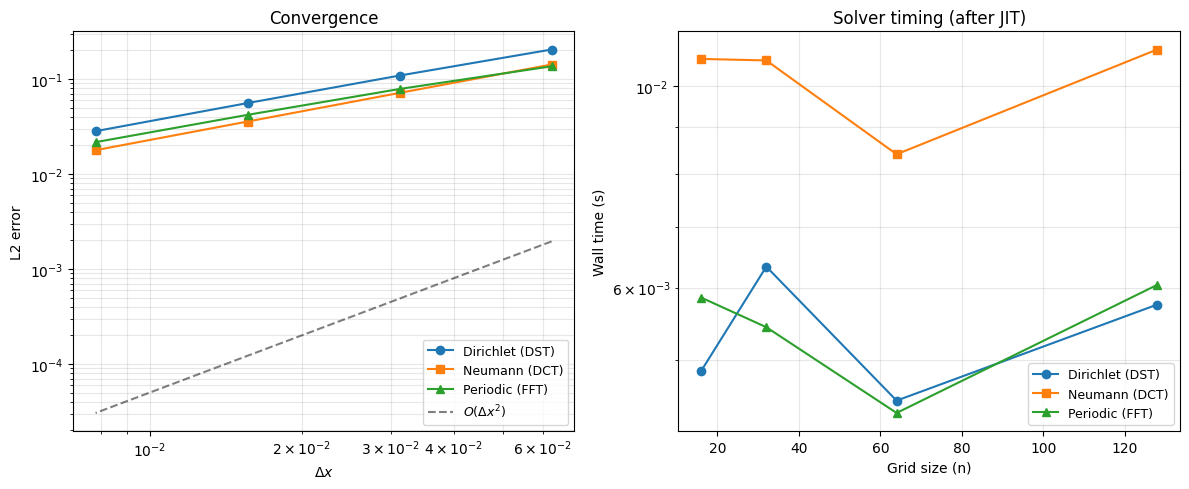

In [7]:
dx_vals = [1.0 / n for n in resolutions]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -- Convergence --
ax = axes[0]
ax.loglog(dx_vals, errors_dir, "o-", label="Dirichlet (DST)")
ax.loglog(dx_vals, errors_neu, "s-", label="Neumann (DCT)")
ax.loglog(dx_vals, errors_per, "^-", label="Periodic (FFT)")
# Reference O(dx^2) line
dx_ref = jnp.array(dx_vals)
ax.loglog(dx_vals, 0.5 * dx_ref**2, "k--", alpha=0.5, label=r"$O(\Delta x^2)$")
ax.set_xlabel(r"$\Delta x$")
ax.set_ylabel("L2 error")
ax.set_title("Convergence")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which="both")

# -- Timing --
ax = axes[1]
ax.semilogy(resolutions, times_dir, "o-", label="Dirichlet (DST)")
ax.semilogy(resolutions, times_neu, "s-", label="Neumann (DCT)")
ax.semilogy(resolutions, times_per, "^-", label="Periodic (FFT)")
ax.set_xlabel("Grid size (n)")
ax.set_ylabel("Wall time (s)")
ax.set_title("Solver timing (after JIT)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## Summary

| BC type | Spectral method | Test function | somax API |
|-----------|--------|-----------|
| Dirichlet | DST | `"dirichlet"` |
| Neumann | DCT | `"neumann"` |
| Periodic | FFT | `"periodic"` |

All three methods converge at $O(\Delta x^2)$ and run in $O(N \log N)$ time.  The Poisson solver is the **key building block** for the pressure projection in Steps 12 and 13.

**Next:** [Step 11](step11_helmholtz_2d) extends the Poisson solver with a Helmholtz (screening) term.